# Week 13 숙제: Optimizer 비교 실험

## 학습 목표

- SGD / Momentum / RMSProp / Adam 의 **수식을 직접 구현**
- IRIS / MNIST 에서 4 종 optimizer 의 **수렴 속도와 최종 성능** 비교
- 학습률(`lr`) 변화에 대한 **민감도** 측정

## 제출 방법

- 이 노트북을 끝까지 실행한 결과를 저장해서 제출 (채점자가 결과를 추가 실행 없이 확인할 수 있게)
- 코드 빈칸(`# 구현 위치`) 을 모두 채우고
- 마지막 **분석 질문 4 개**에 본인 의견을 작성

---

## 시작 전 확인

`neural_network_v2.py` 가 노트북과 같은 폴더에 있어야 한다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neural_network_v2 import (
    Network, Dense, ReLU, SoftmaxCE, fit,
    Optimizer,         # base class
)

np.random.seed(0)


---
## Part 1: Optimizer 4 종 직접 구현 (20 점)

`neural_network_v2.py` 의 `Optimizer` base class 를 상속해서 4개 optimizer 를
**직접 구현**한다. 라이브러리의 `SGD/Momentum/RMSProp/Adam` 을 import 하지 **않고**,
수식을 보며 본인이 처음부터 짠다.

### `Optimizer` base class 의 인터페이스

```python
class Optimizer:
    def step(self, net):
        for layer in net.layers:
            for param, grad in layer.params_and_grads():
                self._update(param, grad)

    def _update(self, param, grad):
        raise NotImplementedError
```

- `step(net)` 은 base class 에 이미 구현되어 있음
- **여러분은 `_update(self, param, grad)` 만 override** 하면 됨
- `param` 은 numpy array — `param -= lr * grad` 처럼 **in-place** 로 갱신

### 상태 저장이 필요한 optimizer (Momentum/RMSProp/Adam)

같은 파라미터에 대해 이전 step 의 velocity / 누적 g² 가 필요하다.
`id(param)` 을 key 로 한 dict 로 저장:

```python
self.v = {}
def _update(self, param, grad):
    key = id(param)
    if key not in self.v:
        self.v[key] = np.zeros_like(param)
    # 여기서 self.v[key] 업데이트
```

### 1.1 MySGD (5 점)

$$\theta \leftarrow \theta - \eta \cdot \nabla L$$

In [2]:

class MySGD(Optimizer):
    def __init__(self, lr=0.01):
        self.lr = lr

    def _update(self, param, grad):
        # 구현: SGD update
        param -= self.lr * grad


### 1.2 MyMomentum (5 점)

$$v \leftarrow \mu \cdot v - \eta \cdot \nabla L$$
$$\theta \leftarrow \theta + v$$

In [3]:

class MyMomentum(Optimizer):
    def __init__(self, lr=0.01, mu=0.9):
        self.lr = lr
        self.mu = mu
        self.v = {}   # id(param) -> velocity

    def _update(self, param, grad):
        key = id(param)
        if key not in self.v:
            self.v[key] = np.zeros_like(param)
        # 구현: velocity update
        self.v[key] = self.mu * self.v[key] - self.lr * grad
        # 구현: parameter update (in-place)
        param += self.v[key]


### 1.3 MyRMSProp (5 점)

$$s \leftarrow \rho \cdot s + (1-\rho) \cdot g^2$$
$$\theta \leftarrow \theta - \eta \cdot \frac{g}{\sqrt{s} + \epsilon}$$

In [4]:

class MyRMSProp(Optimizer):
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.s = {}

    def _update(self, param, grad):
        key = id(param)
        if key not in self.s:
            self.s[key] = np.zeros_like(param)
        # 구현: squared-gradient moving average
        self.s[key] = self.rho * self.s[key] + (1 - self.rho) * (grad ** 2)
        # 구현: parameter update (in-place)
        param -= self.lr * grad / (np.sqrt(self.s[key]) + self.eps)


### 1.4 MyAdam (5 점)

$$m \leftarrow \beta_1 \cdot m + (1-\beta_1) \cdot g$$
$$v \leftarrow \beta_2 \cdot v + (1-\beta_2) \cdot g^2$$
$$\hat{m} = m / (1 - \beta_1^t), \quad \hat{v} = v / (1 - \beta_2^t)$$
$$\theta \leftarrow \theta - \eta \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

**주의**: 시간 step `t` 가 필요. `step()` 호출마다 1 씩 증가하도록 `step` 을 override.

In [5]:

class MyAdam(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}     # first moment
        self.v = {}     # second moment
        self.t = 0      # time step

    def step(self, net):
        # 구현: time step 증가 후 base optimizer step 호출
        self.t += 1
        super().step(net)

    def _update(self, param, grad):
        key = id(param)
        if key not in self.m:
            self.m[key] = np.zeros_like(param)
            self.v[key] = np.zeros_like(param)
        # 구현: first/second moment update
        self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grad
        self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grad ** 2)
        # 구현: bias correction
        m_hat = self.m[key] / (1 - self.beta1 ** self.t)
        v_hat = self.v[key] / (1 - self.beta2 ** self.t)
        # 구현: parameter update (in-place)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


### 1.5 동작 확인 (검증용)

XOR 에서 4개 모두 학습되는지 확인. 1000 epoch 안에 loss < 0.05 가 나와야 정상.

In [6]:
def test_xor(OptCls, name, lr, **kw):
    np.random.seed(0)
    X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
    Y = np.array([[0],[1],[1],[0]], dtype=float)
    from neural_network_v2 import MSELoss
    net = Network()
    net.add(Dense(2, 8, seed=0))
    net.add(ReLU())
    net.add(Dense(8, 1, seed=1))
    loss_fn = MSELoss()
    opt = OptCls(lr=lr, **kw)
    for _ in range(1500):
        pred = net.forward(X)
        l = loss_fn.forward(pred, Y)
        net.backward(loss_fn.backward())
        opt.step(net)
    status = '✓' if l < 0.05 else '✗'
    print(f"{status} {name:10s} (lr={lr}): final loss={l:.4f}")

test_xor(MySGD,      'MySGD',      0.1)
test_xor(MyMomentum, 'MyMomentum', 0.01, mu=0.9)
test_xor(MyRMSProp,  'MyRMSProp',  0.05)
test_xor(MyAdam,     'MyAdam',     0.05)


✓ MySGD      (lr=0.1): final loss=0.0000
✓ MyMomentum (lr=0.01): final loss=0.0000
✓ MyRMSProp  (lr=0.05): final loss=0.0023
✓ MyAdam     (lr=0.05): final loss=0.0000


---
## Part 2: IRIS optimizer 비교 (25 점)

같은 네트워크 (4→16→3), 같은 데이터, 같은 epoch 수에서 4 개 optimizer 의 학습 곡선을 비교.

**공정한 비교를 위해**:
- 매 실험마다 `np.random.seed(0)` 으로 가중치 초기화 고정
- 같은 미니배치 순서를 위해 학습 안에서도 seed 고정

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
Y = np.eye(3)[iris.target]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=iris.target)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (105, 4), Test: (45, 4)


### 2.1 4 종 비교 실험 (15 점)

각 optimizer 의 학습률은 아래 표를 사용 (수업 슬라이드 권장값):

| Optimizer | lr | 기타 |
|-----------|----|------|
| MySGD | 0.05 | |
| MyMomentum | 0.01 | mu=0.9 |
| MyRMSProp | 0.005 | rho=0.9 |
| MyAdam | 0.01 | beta1=0.9, beta2=0.999 |

In [8]:

def train_iris(OptCls, **kw):
    # 구현: Iris optimizer 비교 학습 루프
    # 1) np.random.seed(0)  <- 가중치 초기화 고정
    np.random.seed(0)
    # 2) Network 조립: Dense(4,16) -> ReLU -> Dense(16,3)
    net = Network()
    net.add(Dense(4, 16))
    net.add(ReLU())
    net.add(Dense(16, 3))
    # 3) loss_fn = SoftmaxCE()
    loss_fn = SoftmaxCE()
    # 4) opt = OptCls(**kw)
    opt = OptCls(**kw)
    # 5) np.random.seed(0)  <- 미니배치 순서 고정
    np.random.seed(0)
    # 6) fit(...) 호출하고 history 반환
    history = fit(net, X_train, Y_train, loss_fn, opt, epochs=100, batch_size=16, verbose=False)
    # 7) test accuracy 계산
    y_pred = net.forward(X_test).argmax(axis=1)
    y_true = Y_test.argmax(axis=1)
    test_acc = np.mean(y_pred == y_true)
    # 반환: (history['loss'], test_acc)
    return history["loss"], test_acc

configs = [
    ('MySGD',      MySGD,      dict(lr=0.05)),
    ('MyMomentum', MyMomentum, dict(lr=0.01, mu=0.9)),
    ('MyRMSProp',  MyRMSProp,  dict(lr=0.005)),
    ('MyAdam',     MyAdam,     dict(lr=0.01)),
]

results = {}
for name, OptCls, kw in configs:
    losses, acc = train_iris(OptCls, **kw)
    results[name] = (losses, acc)
    print(f"{name:11s}  final loss={losses[-1]:.4f}  test_acc={acc:.1%}")


MySGD        final loss=0.0854  test_acc=97.8%
MyMomentum   final loss=0.0574  test_acc=97.8%
MyRMSProp    final loss=0.0505  test_acc=97.8%
MyAdam       final loss=0.0394  test_acc=97.8%


### 2.2 학습 곡선 시각화 (10 점)

4 개 optimizer 의 loss curve 를 한 그림에 그린다. y 축은 log scale.

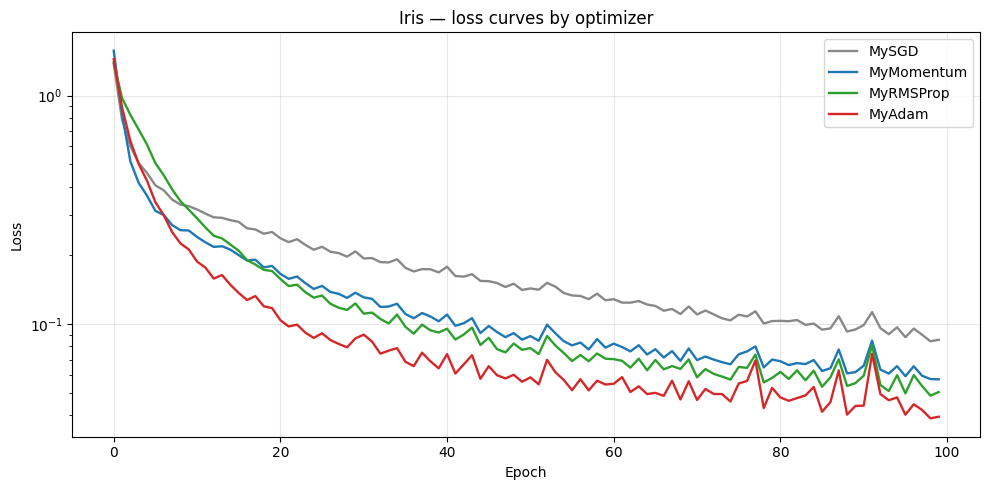

In [9]:
#아래 코드를 이용하거나 별도의 코드를 작성
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'MySGD': '#888', 'MyMomentum': '#1f77b4',
          'MyRMSProp': '#2ca02c', 'MyAdam': '#d62728'}
for name, (losses, _) in results.items():
    ax.plot(losses, label=name, color=colors[name], lw=1.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Iris — loss curves by optimizer')
plt.tight_layout(); plt.show()



### Iris per-sample CE / margin classification diagnostics

optimizer별 train loss 감소 속도 비교에서 accuracy가 모두 같을 때, confusion matrix / macro-F1 / per-sample CE / margin으로 optimizer별 예측 품질 차이를 더 세밀하게 확인한다.


,optimizer,final_loss,test_accuracy,macro_f1,mean_per_sample_ce,mean_margin
0,MySGD,0.085444,0.977778,0.977753,0.167875,3.743163
1,MyMomentum,0.057353,0.977778,0.977753,0.135573,4.828175
2,MyRMSProp,0.050463,0.977778,0.977753,0.301048,9.458655
3,MyAdam,0.039351,0.977778,0.977753,0.115966,6.534146


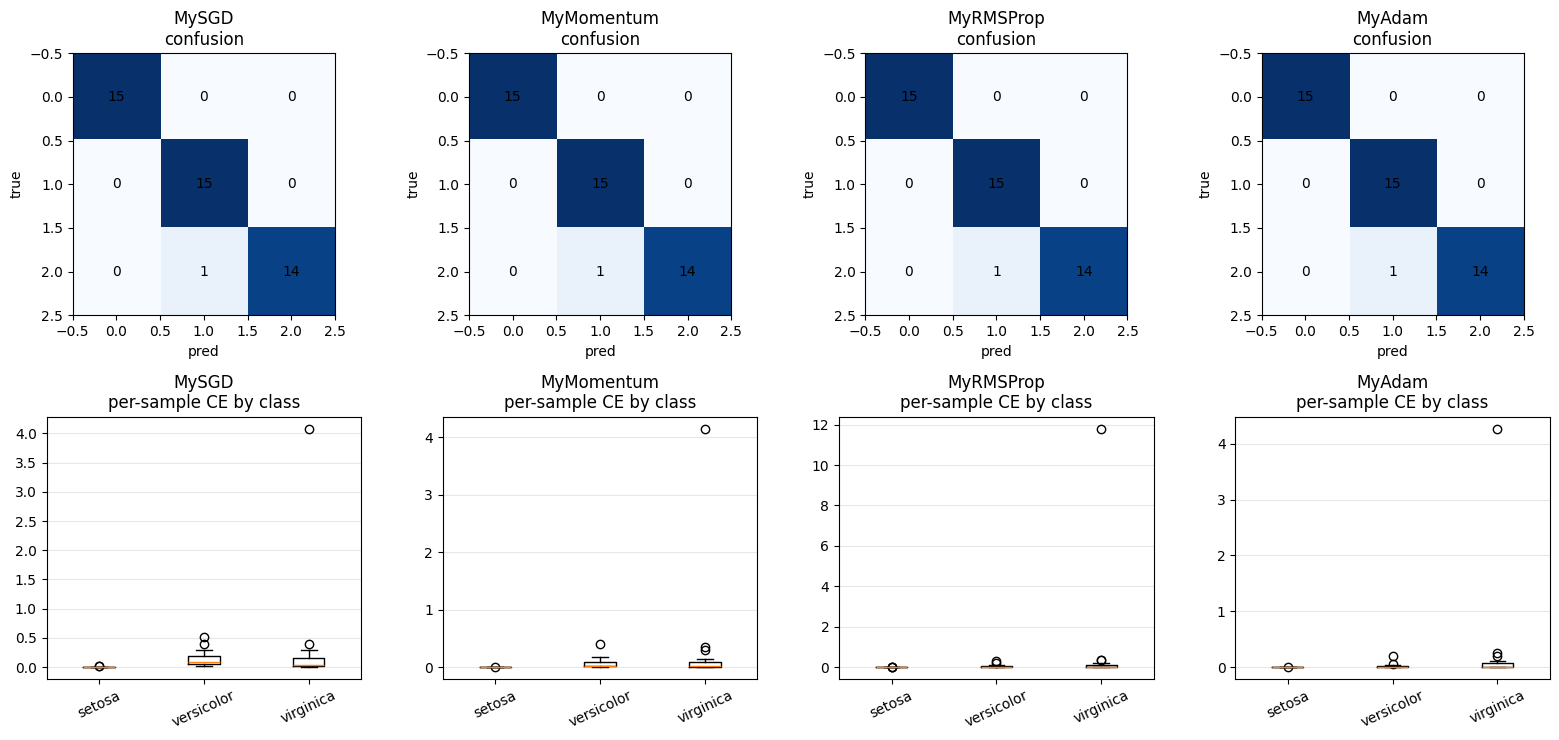

In [10]:

# Iris per-sample CE / margin classification diagnostics
from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

def softmax_ext(logits_ext):
    shifted_ext = logits_ext - np.max(logits_ext, axis=1, keepdims=True)
    exp_ext = np.exp(shifted_ext)
    return exp_ext / exp_ext.sum(axis=1, keepdims=True)

def train_iris_diagnostic_ext(OptCls, **kw):
    np.random.seed(0)
    net_ext = Network()
    net_ext.add(Dense(4, 16))
    net_ext.add(ReLU())
    net_ext.add(Dense(16, 3))
    loss_fn_ext = SoftmaxCE()
    opt_ext = OptCls(**kw)
    np.random.seed(0)
    history_ext = fit(net_ext, X_train, Y_train, loss_fn_ext, opt_ext, epochs=100, batch_size=16, verbose=False)
    logits_ext = net_ext.forward(X_test)
    probs_ext = softmax_ext(logits_ext)
    y_true_ext = Y_test.argmax(axis=1)
    y_pred_ext = probs_ext.argmax(axis=1)
    p_true_ext = probs_ext[np.arange(len(y_true_ext)), y_true_ext]
    per_sample_ce_ext = -np.log(np.clip(p_true_ext, 1e-12, 1.0))
    other_logits_ext = logits_ext.copy()
    other_logits_ext[np.arange(len(y_true_ext)), y_true_ext] = -np.inf
    margin_ext = logits_ext[np.arange(len(y_true_ext)), y_true_ext] - np.max(other_logits_ext, axis=1)
    ce_margin_df_ext = pd.DataFrame({
        "sample_id": np.arange(len(y_true_ext)),
        "y_true": y_true_ext,
        "y_pred": y_pred_ext,
        "class_name": [iris.target_names[i] for i in y_true_ext],
        "p_true": p_true_ext,
        "per_sample_ce": per_sample_ce_ext,
        "margin": margin_ext,
        "correct": y_true_ext == y_pred_ext,
    })
    return net_ext, history_ext, ce_margin_df_ext, confusion_matrix(y_true_ext, y_pred_ext)

diag_iris_rows_ext = []
diag_ce_margin_tables_ext = []
diag_confusions_ext = {}
for name_ext, OptCls_ext, kw_ext in configs:
    net_ext, hist_ext, ce_margin_df_ext, cm_ext = train_iris_diagnostic_ext(OptCls_ext, **kw_ext)
    ce_margin_df_ext["optimizer"] = name_ext
    diag_ce_margin_tables_ext.append(ce_margin_df_ext)
    diag_confusions_ext[name_ext] = cm_ext
    diag_iris_rows_ext.append({
        "optimizer": name_ext,
        "final_loss": float(hist_ext["loss"][-1]),
        "test_accuracy": float((ce_margin_df_ext["y_true"] == ce_margin_df_ext["y_pred"]).mean()),
        "macro_f1": float(f1_score(ce_margin_df_ext["y_true"], ce_margin_df_ext["y_pred"], average="macro")),
        "mean_per_sample_ce": float(ce_margin_df_ext["per_sample_ce"].mean()),
        "mean_margin": float(ce_margin_df_ext["margin"].mean()),
    })

diag_iris_summary_ext = pd.DataFrame(diag_iris_rows_ext)
diag_iris_ce_margin_ext = pd.concat(diag_ce_margin_tables_ext, ignore_index=True)
display(diag_iris_summary_ext)
diag_iris_summary_ext.to_csv(csv_dir_ext / "iris_ce_margin_diagnostic_summary.csv", index=False)
diag_iris_ce_margin_ext.to_csv(csv_dir_ext / "iris_classification_ce_margin.csv", index=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax_ext, (name_ext, cm_ext) in zip(axes[0], diag_confusions_ext.items()):
    ax_ext.imshow(cm_ext, cmap="Blues")
    ax_ext.set_title(f"{name_ext}\nconfusion")
    ax_ext.set_xlabel("pred")
    ax_ext.set_ylabel("true")
    for i_ext in range(cm_ext.shape[0]):
        for j_ext in range(cm_ext.shape[1]):
            ax_ext.text(j_ext, i_ext, int(cm_ext[i_ext, j_ext]), ha="center", va="center")

for ax_ext, name_ext in zip(axes[1], diag_confusions_ext.keys()):
    data_ext = [
        diag_iris_ce_margin_ext[
            (diag_iris_ce_margin_ext["optimizer"] == name_ext)
            & (diag_iris_ce_margin_ext["y_true"] == cls_ext)
        ]["per_sample_ce"]
        for cls_ext in range(3)
    ]
    ax_ext.boxplot(data_ext, tick_labels=iris.target_names)
    ax_ext.set_title(f"{name_ext}\nper-sample CE by class")
    ax_ext.tick_params(axis="x", rotation=25)
    ax_ext.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(fig_dir_ext / "iris_ce_margin_confusion_diagnostics.png", dpi=160)
plt.show()



### **Iris Optimizer 실험 진단 요약**

네 가지 옵티마이저 모두 Iris 데이터에서 **동일한 test accuracy**를 달성했지만, loss 곡선이나 최종 손실값은 **옵티마이저별로 다르게 나타난다.**

- **Accuracy**는 단순히 argmax 클래스가 맞았는지만 평가하나, **Cross-Entropy 손실**은 정답 클래스에 부여된 **신뢰도(확률)**까지 반영한다.
- 분류 문제에서는 회귀처럼 `y - y_hat` residual을 직접 해석하지 않으므로, 여기서는 **per-sample CE**, **margin**, **confusion matrix**를 보조 진단 지표로 사용한다.

따라서 단순 정확도만 보면 차이를 발견하기 어렵지만, 모델이 정답 class에 얼마나 안정적으로 높은 확률을 부여했는지는 per-sample CE와 margin으로 더 세밀하게 확인할 수 있다.



---
## Part 3: MNIST optimizer 비교 (25 점)

더 어려운 문제에서 차이가 더 뚜렷해진다. Iris 와 같은 4 종 optimizer 를 MNIST 에서 비교.

### 3.1 데이터 로드

MNIST cell은 실행 결과를 저장해 제출하며, fresh environment에서는 TensorFlow/Keras MNIST cache 또는 internet access가 필요할 수 있다.


In [11]:
import os

X = y = None

# 1) 저장된 Keras MNIST cache를 먼저 직접 읽는다. 이 경로가 있으면 TensorFlow import가 필요 없어 warning output이 생기지 않는다.
keras_cache_path = os.path.expanduser("~/.keras/datasets/mnist.npz")
if X is None and os.path.exists(keras_cache_path):
    with np.load(keras_cache_path) as data:
        X_tr, y_tr = data["x_train"], data["y_train"]
        X_te, y_te = data["x_test"], data["y_test"]
    X = np.concatenate([X_tr, X_te]).reshape(-1, 784)
    y = np.concatenate([y_tr, y_te])

# 2) cache가 없는 fresh environment에서는 TensorFlow/Keras loader를 fallback으로 사용한다.
if X is None:
    try:
        os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
        from tensorflow.keras.datasets import mnist as keras_mnist
        (X_tr, y_tr), (X_te, y_te) = keras_mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784)
        y = np.concatenate([y_tr, y_te])
    except Exception:
        pass

# 3) torchvision cache/download fallback.
if X is None:
    try:
        from torchvision import datasets
        root = os.path.expanduser("~/.cache/mnist")
        train = datasets.MNIST(root, train=True,  download=True)
        test  = datasets.MNIST(root, train=False, download=True)
        X = np.concatenate([train.data.numpy(), test.data.numpy()]).reshape(-1, 784)
        y = np.concatenate([train.targets.numpy(), test.targets.numpy()])
    except Exception:
        pass

# 4) 마지막 fallback: OpenML.
if X is None:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data
    y = mnist.target.astype(int)

X = X.astype(np.float32) / 255.0
Y = np.eye(10)[y]

# 빠른 실험을 위해 부분 사용 (학습 8000, 테스트 2000)
n_train, n_test = 8000, 2000
X_train_m = X[:n_train];          Y_train_m = Y[:n_train]
X_test_m  = X[60000:60000+n_test]; Y_test_m  = Y[60000:60000+n_test]
print(f"MNIST train: {X_train_m.shape}, test: {X_test_m.shape}")


MNIST train: (8000, 784), test: (2000, 784)


### 3.2 4 종 비교 학습 (15 점)

네트워크: 784 → 64 → 32 → 10 (작게 잡아 학습 시간 단축).
각 optimizer 5 epoch 만 돌려도 차이가 보임.

In [12]:

# 1. 모델 함수적용용

def train_mnist(OptCls, return_model=False, **kw):
    #MNIST optimizer 비교용 학습 함수.
    #비교 조건:
        #- same architecture
        #- same initialization seed
        #- same mini-batch order
        #- same epochs / batch_size
        #- only optimizer changes

    np.random.seed(0)

    input_dim_m = X_train_m.shape[1]

    net = Network()
    net.add(Dense(input_dim_m, 64))
    net.add(ReLU())
    net.add(Dense(64, 32))
    net.add(ReLU())
    net.add(Dense(32, 10))

    loss_fn = SoftmaxCE()
    opt = OptCls(**kw)

    np.random.seed(0)

    history = fit(
        net,
        X_train_m,
        Y_train_m,
        loss_fn,
        opt,
        epochs=5,
        batch_size=64,
        verbose=False,
    )

    logits = net.forward(X_test_m)
    y_pred = logits.argmax(axis=1)
    y_true = Y_test_m.argmax(axis=1)
    test_acc = np.mean(y_pred == y_true)

    if return_model:
        return history["loss"], test_acc, net

    return history["loss"], test_acc


# 2. Optimizer configs
mnist_configs = [
    ("MySGD",      MySGD,      dict(lr=0.01)),
    ("MyMomentum", MyMomentum, dict(lr=0.005, mu=0.9)),
    ("MyRMSProp",  MyRMSProp,  dict(lr=0.001)),
    ("MyAdam",     MyAdam,     dict(lr=0.001)),
]


# 3. 비교분석
import time

mnist_results = {}
mnist_models = {}

for name, OptCls, kw in mnist_configs:
    t0 = time.time()

    losses, acc, model = train_mnist(
        OptCls,
        return_model=True,
        **kw,
    )

    mnist_results[name] = (losses, acc)
    mnist_models[name] = model

    print(
        f"{name:11s}  "
        f"final loss={losses[-1]:.4f}  "
        f"test_acc={acc:.1%}  "
        f"({time.time() - t0:.1f}s)"
    )

MySGD        final loss=0.4785  test_acc=83.4%  (0.5s)


MyMomentum   final loss=0.2426  test_acc=89.1%  (0.4s)


MyRMSProp    final loss=0.1566  test_acc=90.7%  (4.1s)


MyAdam       final loss=0.1509  test_acc=90.5%  (0.6s)



### 3.3 결과 시각화 (10 점)

MNIST optimizer 비교에서는 Iris보다 optimizer 차이가 더 뚜렷하게 나타난다. Iris는 입력 feature가 4개인 작은 tabular classification 문제였지만, MNIST는 28 x 28 이미지를 flatten한 784차원 입력을 사용한다. 따라서 같은 optimizer라도 더 큰 입력 차원과 더 많은 parameter를 다루게 된다.

이번 실행은 `train 8000 / test 2000 subset`, `5 epoch`, 동일 architecture 조건이다. 결과는 MySGD 83.4%, MyMomentum 89.1%, MyRMSProp 90.7%, MyAdam 90.5%였고, final loss는 각각 0.4785, 0.2426, 0.1566, 0.1509였다. 고정된 epoch budget에서는 SGD의 loss 감소가 상대적으로 느리고, Momentum은 SGD보다 개선되며, RMSProp과 Adam은 gradient 통계를 이용해 update 크기를 조절하므로 더 낮은 loss와 높은 test accuracy를 보였다.

다만 이 결과를 optimizer의 절대 순위로 일반화하면 안 된다. 이 비교는 현재 architecture, subset size, learning rate, epoch 수, batch size 조건에서의 결과다. 따라서 결론은 “항상 Adam이 최우선”이 아니라, “이 MNIST subset과 5 epoch budget에서는 adaptive optimizer가 더 유리했다”로 해석하는 것이 적절하다.


,optimizer,final_loss,test_accuracy,epochs
0,MyRMSProp,0.156582,0.9070,5
1,MyAdam,0.150897,0.9055,5
2,MyMomentum,0.242558,0.8910,5
3,MySGD,0.478496,0.8335,5


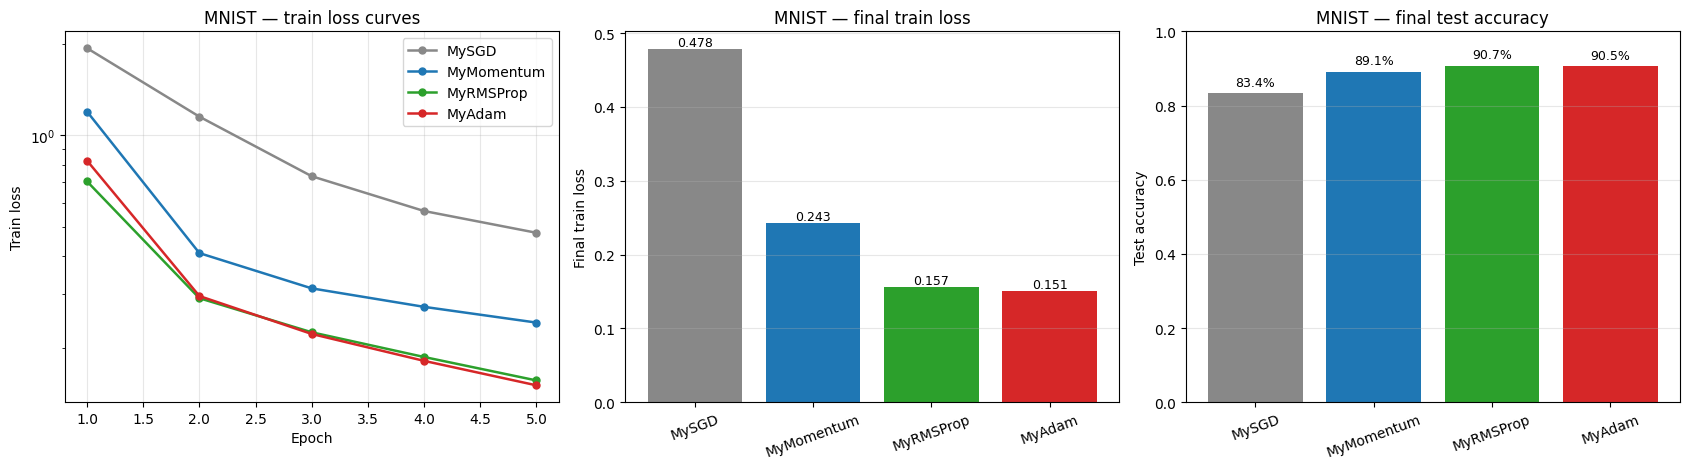

In [13]:
# 1. MNIST 비교 결과 요약표 만들기
mnist_summary = pd.DataFrame(
    [
        {
            "optimizer": name,
            "final_loss": float(losses[-1]),
            "test_accuracy": float(acc),
            "epochs": len(losses),
        }
        for name, (losses, acc) in mnist_results.items()
    ]
)

mnist_summary = mnist_summary.sort_values(
    ["test_accuracy", "final_loss"],
    ascending=[False, True],
).reset_index(drop=True)

display(mnist_summary)

# 2. 시각화 기본 설정
colors = {
    "MySGD": "#888",
    "MyMomentum": "#1f77b4",
    "MyRMSProp": "#2ca02c",
    "MyAdam": "#d62728",
}

names = list(mnist_results.keys())
accs = [mnist_results[n][1] for n in names]
final_losses = [mnist_results[n][0][-1] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))


# 3. Optimizer별 train loss curve 시각화
    # 목적:
        # 1) 같은 epoch budget 안에서 optimizer별 loss 감소 속도를 비교한다.
        # 2) y축은 log scale로 두어 초반/후반 loss 차이를 함께 보기 쉽게 한다.
for name, (losses, _) in mnist_results.items():
    axes[0].plot(
        range(1, len(losses) + 1),
        losses,
        "o-",
        label=name,
        color=colors[name],
        lw=1.8,
        ms=5,
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_yscale("log")
axes[0].set_title("MNIST — train loss curves")
axes[0].grid(alpha=0.3)
axes[0].legend()


#4. Optimizer별 final train loss 비교
    # 목적:
        # 1) 마지막 epoch 기준으로 optimizer별 train loss가 어디까지 내려갔는지 비교한다.
        # 2) accuracy가 비슷하더라도 final loss가 다르면 정답 class에 대한 확신도가 다를 수 있다.

axes[1].bar(
    names,
    final_losses,
    color=[colors[n] for n in names],
)

axes[1].set_ylabel("Final train loss")
axes[1].set_title("MNIST — final train loss")
axes[1].grid(axis="y", alpha=0.3)

for i, loss in enumerate(final_losses):
    axes[1].text(
        i,
        loss,
        f"{loss:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[1].tick_params(axis="x", rotation=20)


#5. Optimizer별 final test accuracy 비교
    # 목적:
        # 1) 학습에 사용하지 않은 test subset에서 optimizer별 최종 분류 성능을 비교한다.
        # 2) test accuracy는 최종 평가 지표이고, train loss와 함께 해석해야 한다.

axes[2].bar(
    names,
    accs,
    color=[colors[n] for n in names],
)

axes[2].set_ylabel("Test accuracy")
axes[2].set_ylim(0, 1)
axes[2].set_title("MNIST — final test accuracy")
axes[2].grid(axis="y", alpha=0.3)

for i, acc in enumerate(accs):
    axes[2].text(
        i,
        acc + 0.02,
        f"{acc:.1%}",
        ha="center",
        fontsize=9,
    )

axes[2].tick_params(axis="x", rotation=20)


#6. 결과 저장 및 출력

plt.tight_layout()

try:
    fig_dir_ext.mkdir(parents=True, exist_ok=True)
    csv_dir_ext.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        fig_dir_ext / "mnist_optimizer_result_visualization.png",
        dpi=160,
    )

    mnist_summary.to_csv(
        csv_dir_ext / "mnist_optimizer_summary.csv",
        index=False,
    )
except NameError:
    pass

plt.show()


## Part 4: 학습률 민감도 (10 점)

같은 optimizer 라도 학습률에 따라 결과가 크게 달라진다.
**Adam** vs **SGD** 의 학습률 민감도를 비교한다.

각 optimizer 를 학습률 4개 (`1e-4, 1e-3, 1e-2, 1e-1`) 로 IRIS 학습. 최종 test accuracy 를 plot.

Part 2/3의 비교는 순수한 same-lr optimizer 비교가 아니라, 과제에서 권장한 optimizer별 learning rate configuration 비교다. Part 4는 MySGD와 MyAdam을 같은 lr grid에서 돌려 learning rate 민감도를 따로 확인한다.

SGD는 현재 gradient를 그대로 사용해 `param -= lr * grad`로 update하므로, learning rate가 너무 작으면 학습이 느리고 너무 크면 불안정해질 수 있다. Adam은 gradient의 1차 모멘트와 2차 모멘트를 사용해 update 크기를 조절하지만, Adam 역시 learning rate에서 자유로운 것은 아니다. learning rate가 지나치게 크면 Adam도 불안정해질 수 있다.

따라서 이 실험의 결론은 “Adam이 항상 SGD보다 좋다”가 아니라, “optimizer의 update rule과 learning rate가 함께 성능을 결정한다”이다. 또한 Iris는 작은 데이터셋이므로 accuracy가 쉽게 포화될 수 있다. 그러므로 test accuracy뿐 아니라 loss curve, final loss, sensitivity range를 함께 해석하는 것이 적절하다.


lr=0.0001  MySGD=42.2%  MyAdam=44.4%
lr=0.001  MySGD=68.9%  MyAdam=95.6%
lr=0.01  MySGD=91.1%  MyAdam=97.8%
lr=0.1  MySGD=97.8%  MyAdam=97.8%


,lr,MySGD_test_acc,MyAdam_test_acc,Adam_minus_SGD
0,0.0001,0.422222,0.444444,0.022222
1,0.0010,0.688889,0.955556,0.266667
2,0.0100,0.911111,0.977778,0.066667
3,0.1000,0.977778,0.977778,0.000000


,optimizer,best_lr,best_acc,worst_acc,sensitivity_range
0,MySGD,0.10,0.977778,0.422222,0.555556
1,MyAdam,0.01,0.977778,0.444444,0.533333


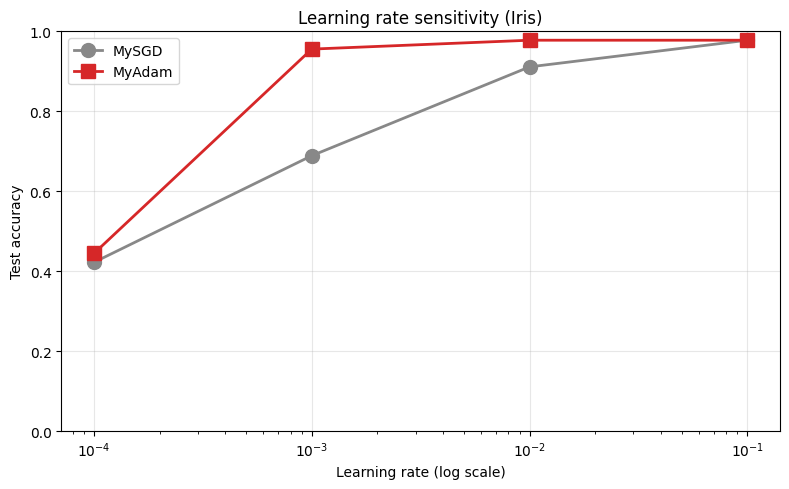

In [14]:

# Phase 1. Learning rate 후보 설정

# 같은 optimizer라도 learning rate에 따라 test accuracy가 크게 달라질 수 있다.
# 여기서는 MySGD와 MyAdam을 같은 Iris 데이터와 같은 train_iris 함수로 비교한다.
#
# 비교 대상 learning rate:
#   1e-4, 1e-3, 1e-2, 1e-1
#
# 핵심 비교:
#   - MySGD는 lr 변화에 얼마나 민감한가?
#   - MyAdam은 lr 변화에 얼마나 민감한가?
#   - 특정 lr에서 Adam이 항상 SGD보다 좋은가?

lrs = [1e-4, 1e-3, 1e-2, 1e-1]


# Phase 2. 각 learning rate에서 MySGD / MyAdam 학습

sgd_accs = []
adam_accs = []
for lr in lrs:
    _, sgd_acc = train_iris(MySGD, lr=lr)
    _, adam_acc = train_iris(MyAdam, lr=lr)

    sgd_accs.append(sgd_acc)
    adam_accs.append(adam_acc)

    print(
        f"lr={lr:g}  "
        f"MySGD={sgd_acc:.1%}  "
        f"MyAdam={adam_acc:.1%}"
    )


# Phase 3. LR sensitivity summary table 생성
# 공식 plot에 들어가는 값을 표로 정리한다.

# Adam_minus_SGD:
#   같은 learning rate에서 Adam test accuracy - SGD test accuracy

# 이 값이 양수이면:
#   해당 lr에서 Adam이 SGD보다 test accuracy가 높다.
# 이 값이 0이면:
#   accuracy 기준으로 둘이 같다.
# 이 값이 음수이면:
#   해당 lr에서 SGD가 Adam보다 test accuracy가 높다.

lr_sensitivity_df = pd.DataFrame(
    {
        "lr": lrs,
        "MySGD_test_acc": sgd_accs,
        "MyAdam_test_acc": adam_accs,
    }
)

lr_sensitivity_df["Adam_minus_SGD"] = (
    lr_sensitivity_df["MyAdam_test_acc"]
    - lr_sensitivity_df["MySGD_test_acc"]
)

display(lr_sensitivity_df)


# Phase 4. Optimizer별 best/worst/range 요약

# best_lr:
#   해당 optimizer가 가장 높은 test accuracy를 보인 learning rate
# best_acc:
#   최고 test accuracy

# worst_acc:
#   최저 test accuracy
# sensitivity_range:
#   best_acc - worst_acc

# 해석:
#   range가 클수록 learning rate 선택에 민감하다.
#   range가 작을수록 이 lr grid 안에서는 상대적으로 안정적이다.

lr_summary = pd.DataFrame(
    [
        [
            "MySGD",
            lrs[int(np.argmax(sgd_accs))],
            float(np.max(sgd_accs)),
            float(np.min(sgd_accs)),
            float(np.max(sgd_accs) - np.min(sgd_accs)),
        ],
        [
            "MyAdam",
            lrs[int(np.argmax(adam_accs))],
            float(np.max(adam_accs)),
            float(np.min(adam_accs)),
            float(np.max(adam_accs) - np.min(adam_accs)),
        ],
    ],
    columns=[
        "optimizer",
        "best_lr",
        "best_acc",
        "worst_acc",
        "sensitivity_range",
    ],
)

display(lr_summary)


# Phase 5. Learning rate sensitivity plot
# x축:
#   learning rate. 값이 1e-4 ~ 1e-1로 scale 차이가 크므로 log scale 사용.

# y축:
#   test accuracy.

# semilogx:
#   x축만 log scale로 그리는 matplotlib 함수.

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(
    lrs,
    sgd_accs,
    "o-",
    label="MySGD",
    color="#888",
    lw=2,
    ms=10,
)

ax.semilogx(
    lrs,
    adam_accs,
    "s-",
    label="MyAdam",
    color="#d62728",
    lw=2,
    ms=10,
)

ax.set_xlabel("Learning rate (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Learning rate sensitivity (Iris)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()


# Phase 6. 결과 출력



try:
    fig_dir_ext.mkdir(parents=True, exist_ok=True)
    csv_dir_ext.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        fig_dir_ext / "part4_lr_sensitivity_iris.png",
        dpi=160,
    )

    lr_sensitivity_df.to_csv(
        csv_dir_ext / "part4_lr_sensitivity_table.csv",
        index=False,
    )

    lr_summary.to_csv(
        csv_dir_ext / "part4_lr_sensitivity_summary.csv",
        index=False,
    )
except NameError:
    pass

plt.show()

### [추가] 

이 확장 cell은 Part 4의 learning rate sensitivity를 이후 Q4의 optimizer 선택 근거로 연결하기 위한 추가 삽입 셀입니다.  실제 Iris/MNIST 노트북 점수 산출을 대체하지 않고, synthetic 2D quadratic surface에서 같은 gradient를 받은 optimizer들이 서로 다른 update path와 state를 만드는 과정을 시각화합니다.

,optimizer,step,w0,w1,loss,grad_norm,update_norm,state_norm
45,MySGD,45,0.960365,3.311703e-25,0.092230,0.192073,0.035864,0.000000
91,MyMomentum,45,-0.501832,-9.272764e-02,0.042380,0.384250,0.113996,0.113996
137,MyRMSProp,45,1.326116,1.876666e-02,0.176563,0.275642,0.055935,2.035072
183,MyAdam,45,1.796175,-5.654882e-02,0.329020,0.424516,0.057912,1.594512


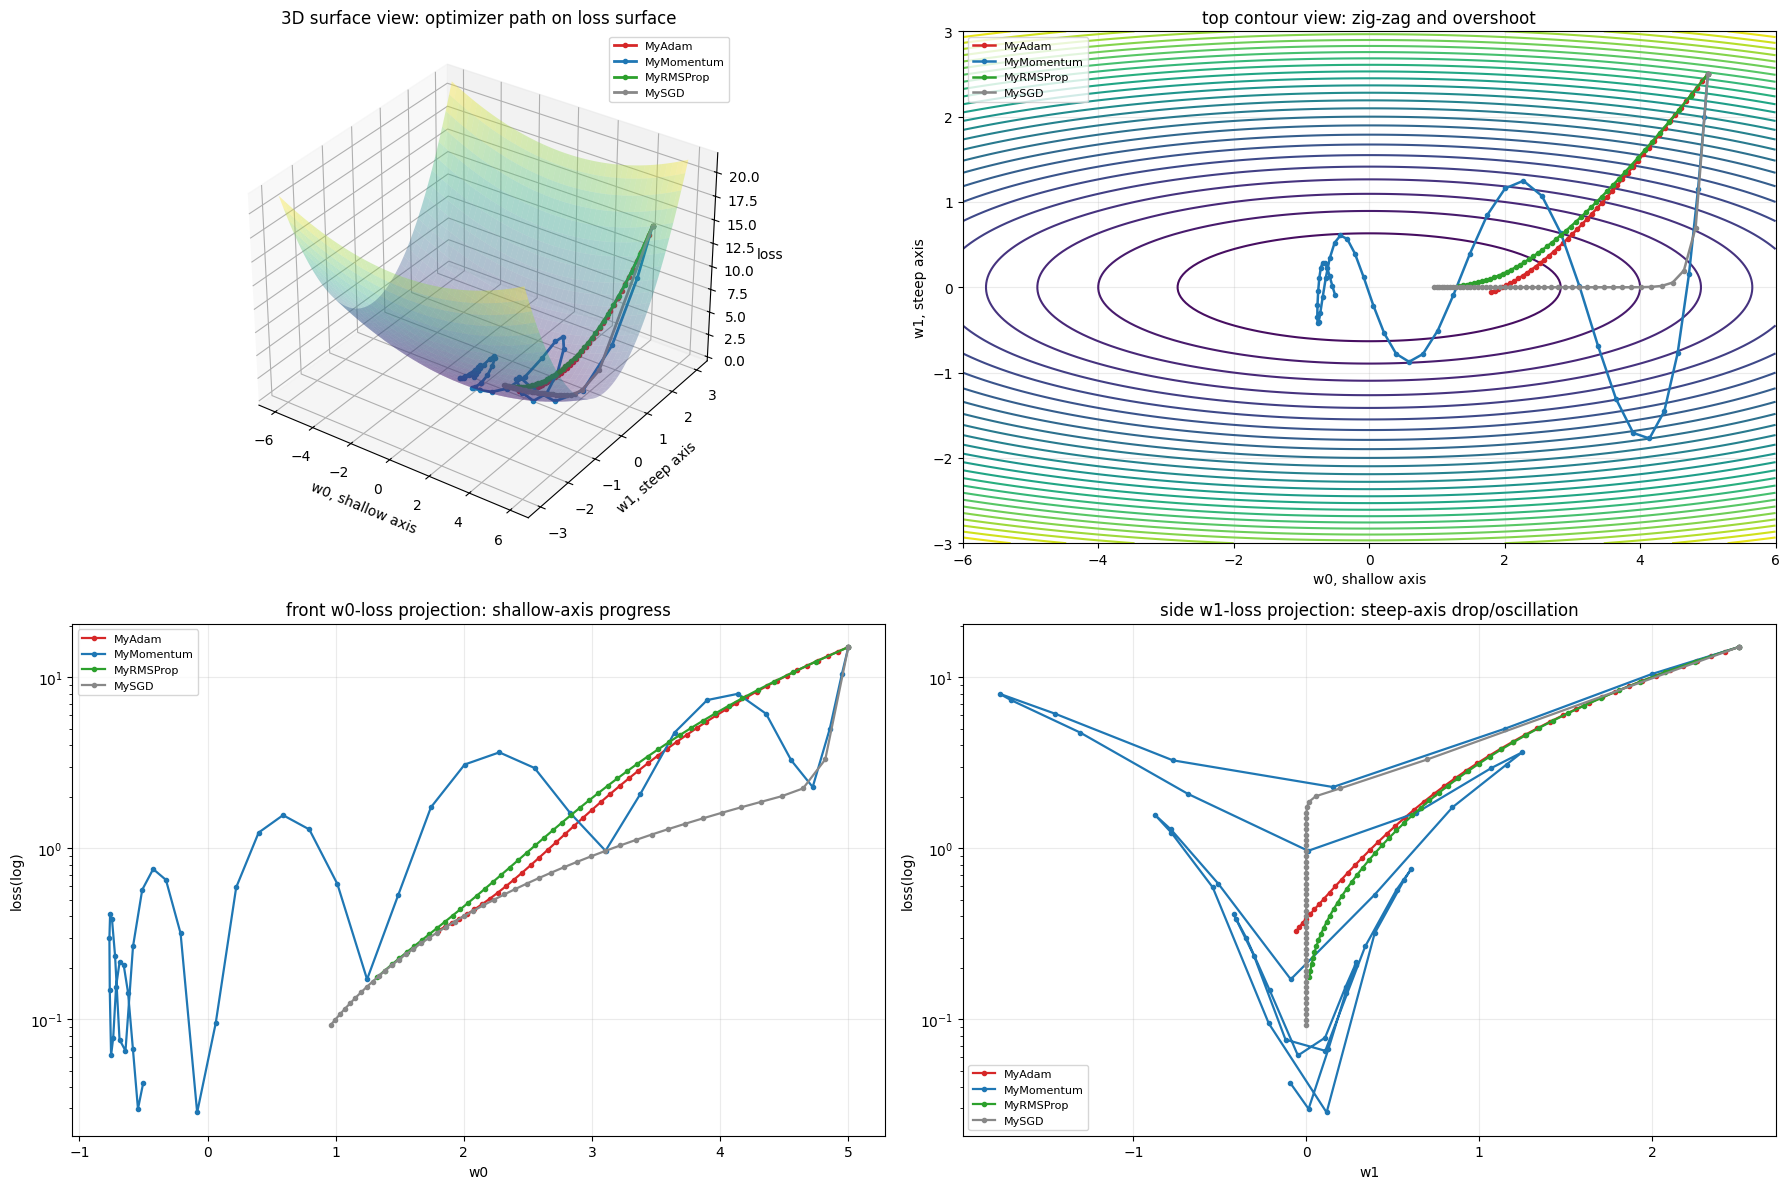

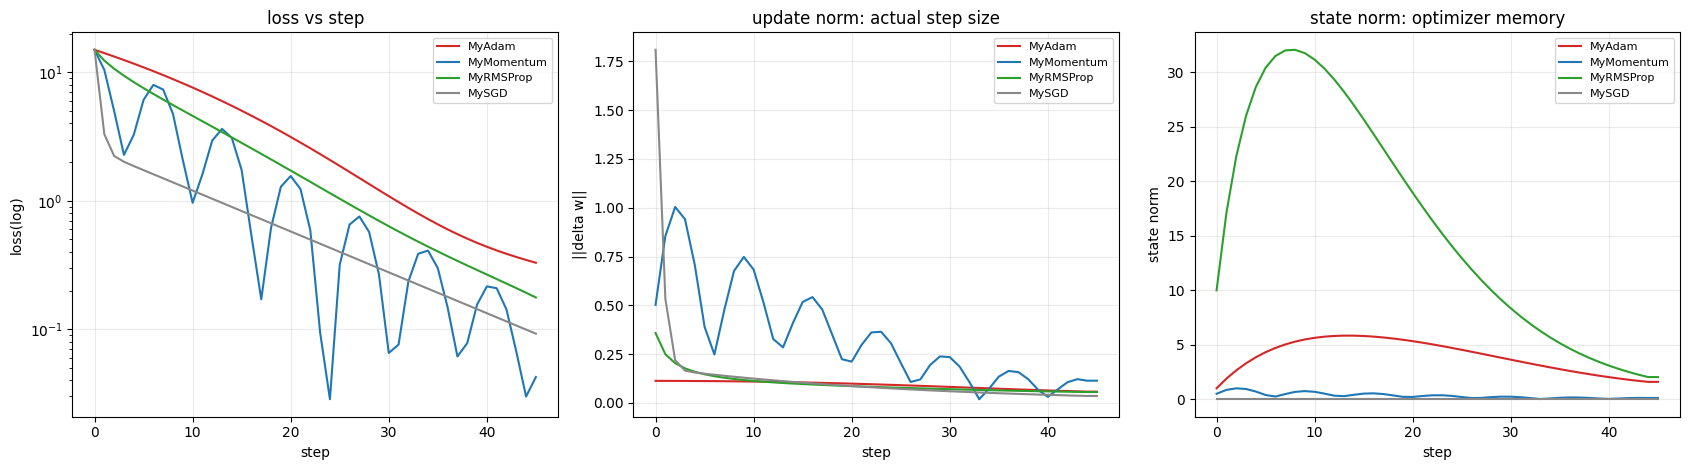

,view,what to read,Q4 interpretation
0,3D surface view,loss surface 전체 공간감,optimizer path가 valley를 향해 내려오는 전체 방향을 설명한다.
1,top contour view,zig-zag와 overshoot,"w0/w1 평면에서 경로가 흔들리는지, 곡률 방향을 따라 안정적으로 가는지 본다."
2,front w0-loss projection,완만한 축 w0의 loss 감소,w0는 gradient가 작아 천천히 줄 수 있으므로 optimizer state가...
3,side w1-loss projection,가파른 축 w1의 초반 감소/진동,"steep direction에서 큰 gradient가 overshoot를 만드는지,..."
4,state dashboard,update norm과 optimizer memory,Adam/RMSProp/Momentum이 같은 gradient를 받아도 내부 sta...


In [49]:

# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 추가가 분석/시각화 코드입니다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용합니다.

# 핵심 원칙 : Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.
#---------------------------

# 목적: Part 4의 lr sensitivity 결과를 "왜 optimizer별 update path가 다른가"로 연결한다.
# 원본 Part 4 변수(lrs, sgd_accs, adam_accs)는 그대로 두고, extension-only synthetic 2D surface를 사용한다.
# 이 cell은 공식 점수 산출을 대체하지 않는다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

# w0 방향은 완만하고 w1 방향은 가파른 타원형 loss surface다. 타원형은 overshoot/zig-zag가 잘 보이므로 optimizer path 설명에 적합하다.
def quad_loss_hw_ext(w_ext):
    return 0.1 * w_ext[0] ** 2 + 2.0 * w_ext[1] ** 2

def quad_grad_hw_ext(w_ext):
    # analytic gradient: dL/dw0=0.2*w0, dL/dw1=4.0*w1
    return np.array([0.2 * w_ext[0], 4.0 * w_ext[1]])

class VectorLayerExt:
    # 실제 Dense가 아니어도 같은 interface만 제공하면 optimizer가 param/grad pair만 읽는다는 사실을 확인할 수 있다.
    def __init__(self, w_ext):
        self.w_ext = np.array(w_ext, dtype=float)
        self.grad_ext = np.zeros_like(self.w_ext)

    def params_and_grads(self):
        return [(self.w_ext, self.grad_ext)]

class VectorNetExt:
    def __init__(self, w_ext):
        self.layer_ext = VectorLayerExt(w_ext)
        self.layers = [self.layer_ext]

def run_vector_optimizer_path_ext(OptCls_ext, opt_kwargs_ext, start_ext=(5.0, 2.5), steps_ext=45):
    # 실험 원칙 : same start, same gradient
    # 모든 optimizer는 같은 시작점과 같은 quad_grad를 받는다.
    # path 차이는 gradient 자체가 아니라 update rule/state 차이에서 나온다.
    opt_ext = OptCls_ext(**opt_kwargs_ext)
    net_ext = VectorNetExt(start_ext)
    rows_ext = []
    for step_ext in range(steps_ext + 1):
        w_before_ext = net_ext.layer_ext.w_ext.copy()
        grad_ext = quad_grad_hw_ext(w_before_ext)
        net_ext.layer_ext.grad_ext = grad_ext.copy()
        rows_ext.append({
            "step": step_ext,
            "w0": float(w_before_ext[0]),
            "w1": float(w_before_ext[1]),
            "loss": float(quad_loss_hw_ext(w_before_ext)),
            "grad_norm": float(np.linalg.norm(grad_ext)),
            "update_norm": np.nan,
            "state_norm": np.nan,
        })
        if step_ext == steps_ext:
            break
        opt_ext.step(net_ext)
        update_ext = net_ext.layer_ext.w_ext - w_before_ext

        # Momentum은 v, RMSProp은 s, Adam은 m/v를 dict state로 가진다.
        # state_norm은 trajectory만으로 보이지 않는 optimizer 내부의 크기를 기술술한다.
        state_chunks_ext = []
        for attr_ext in ["v", "s", "m"]:
            state_obj_ext = getattr(opt_ext, attr_ext, None)
            if isinstance(state_obj_ext, dict):
                for value_ext in state_obj_ext.values():
                    state_chunks_ext.append(np.asarray(value_ext).ravel())
        state_norm_ext = float(np.linalg.norm(np.concatenate(state_chunks_ext))) if state_chunks_ext else 0.0
        rows_ext[-1]["update_norm"] = float(np.linalg.norm(update_ext))
        rows_ext[-1]["state_norm"] = state_norm_ext
    return pd.DataFrame(rows_ext)

optimizer_path_specs_ext = [
    ("MySGD", MySGD, dict(lr=0.18)),
    ("MyMomentum", MyMomentum, dict(lr=0.05, mu=0.9)),
    ("MyRMSProp", MyRMSProp, dict(lr=0.08)),
    ("MyAdam", MyAdam, dict(lr=0.08)),
]

trajectory_tables_ext = []
for opt_name_ext, OptCls_ext, kwargs_ext in optimizer_path_specs_ext:
    path_df_ext = run_vector_optimizer_path_ext(OptCls_ext, kwargs_ext)
    path_df_ext["optimizer"] = opt_name_ext
    path_df_ext["lr_used_in_surface"] = kwargs_ext.get("lr")
    trajectory_tables_ext.append(path_df_ext)

optimizer_trajectory_df_ext = pd.concat(trajectory_tables_ext, ignore_index=True)

# 마지막 위치를 기록하는 final row에서는 update를 한 번 더 수행하지 않으므로 update_norm/state_norm을 carry-forward한다.
optimizer_trajectory_df_ext[["update_norm", "state_norm"]] = (
    optimizer_trajectory_df_ext
    .groupby("optimizer")[["update_norm", "state_norm"]]
    .ffill()
    .fillna(0.0)
)
optimizer_trajectory_df_ext.to_csv(csv_dir_ext / "v04_optimizer_trajectory_state_ext.csv", index=False)
display(optimizer_trajectory_df_ext.groupby("optimizer").tail(1)[["optimizer", "step", "w0", "w1", "loss", "grad_norm", "update_norm", "state_norm"]])

# 시각화 
# 1) 3D surface view: 전체 loss surface 공간감
# 2) 평면도 : zig-zag/overshoot 확인
# 3) 정면도 : w0-loss projection: 완만한 w0 축 진행
# 4) 측면도 : w1-loss projection: 가파른 w1 축 감소/진동 --이때 w1은 가상이다.
w0_grid_ext = np.linspace(-6, 6, 180)
w1_grid_ext = np.linspace(-3, 3, 180)
W0_ext, W1_ext = np.meshgrid(w0_grid_ext, w1_grid_ext)
Z_ext = 0.1 * W0_ext ** 2 + 2.0 * W1_ext ** 2
colors_ext = {"MySGD": "#888888", "MyMomentum": "#1f77b4", "MyRMSProp": "#2ca02c", "MyAdam": "#d62728"}

fig = plt.figure(figsize=(18, 12))
ax_surface_ext = fig.add_subplot(2, 2, 1, projection="3d")
ax_top_ext = fig.add_subplot(2, 2, 2)
ax_front_ext = fig.add_subplot(2, 2, 3)
ax_side_ext = fig.add_subplot(2, 2, 4)

# [3D surface view]
ax_surface_ext.plot_surface(W0_ext, W1_ext, Z_ext, cmap="viridis", alpha=0.35, linewidth=0, antialiased=True)
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_surface_ext.plot(
        group_ext["w0"],
        group_ext["w1"],
        group_ext["loss"],
        marker="o",
        markersize=3,
        lw=2,
        label=opt_name_ext,
        color=colors_ext[opt_name_ext],
    )
ax_surface_ext.view_init(elev=32, azim=-55)
ax_surface_ext.set_title("3D surface view: optimizer path on loss surface")
ax_surface_ext.set_xlabel("w0, shallow axis")
ax_surface_ext.set_ylabel("w1, steep axis")
ax_surface_ext.set_zlabel("loss")
ax_surface_ext.legend(fontsize=8)

# [평면도]
ax_top_ext.contour(W0_ext, W1_ext, Z_ext, levels=28, cmap="viridis")
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_top_ext.plot(group_ext["w0"], group_ext["w1"], marker="o", markersize=3, lw=1.8, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_top_ext.set_title("top contour view: zig-zag and overshoot")
ax_top_ext.set_xlabel("w0, shallow axis")
ax_top_ext.set_ylabel("w1, steep axis")
ax_top_ext.legend(fontsize=8)
ax_top_ext.grid(True, alpha=0.25)

# [정면도]
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_front_ext.plot(group_ext["w0"], group_ext["loss"].clip(lower=1e-12), marker="o", markersize=3, lw=1.6, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_front_ext.set_yscale("log")
ax_front_ext.set_title("front w0-loss projection: shallow-axis progress")
ax_front_ext.set_xlabel("w0")
ax_front_ext.set_ylabel("loss(log)")
ax_front_ext.legend(fontsize=8)
ax_front_ext.grid(True, alpha=0.25)

# [측면도]
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_side_ext.plot(group_ext["w1"], group_ext["loss"].clip(lower=1e-12), marker="o", markersize=3, lw=1.6, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_side_ext.set_yscale("log")
ax_side_ext.set_title("side w1-loss projection: steep-axis drop/oscillation")
ax_side_ext.set_xlabel("w1")
ax_side_ext.set_ylabel("loss(log)")
ax_side_ext.legend(fontsize=8)
ax_side_ext.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(fig_dir_ext / "v04_optimizer_surface_projection_pack_ext.png", dpi=160)
plt.show()

# [시각화]
# projection pack이 공간 경로를 보여준다면, state dashboard는 그 경로를 만든 update/state 규모를 보여준다.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    axes[0].plot(group_ext["step"], group_ext["loss"].clip(lower=1e-12), label=opt_name_ext, color=colors_ext[opt_name_ext])
    axes[1].plot(group_ext["step"], group_ext["update_norm"], label=opt_name_ext, color=colors_ext[opt_name_ext])
    axes[2].plot(group_ext["step"], group_ext["state_norm"], label=opt_name_ext, color=colors_ext[opt_name_ext])
axes[0].set_yscale("log")
axes[0].set_title("loss vs step")
axes[1].set_title("update norm: actual step size")
axes[2].set_title("state norm: optimizer memory")
for ax_ext in axes:
    ax_ext.set_xlabel("step")
    ax_ext.grid(True, alpha=0.25)
    ax_ext.legend(fontsize=8)
axes[0].set_ylabel("loss(log)")
axes[1].set_ylabel("||delta w||")
axes[2].set_ylabel("state norm")
plt.tight_layout()
fig.savefig(fig_dir_ext / "v04_optimizer_state_dashboard_ext.png", dpi=160)
plt.show()

# [해석 표 | four-view reading guide]
# 이 표는 네 projection을 어떻게 읽어야 하는지 Part 5 답안용 문장으로 바꿔준다.
v04_projection_reading_guide_ext = pd.DataFrame([
    ["3D surface view", "loss surface 전체 공간감", "optimizer path가 valley를 향해 내려오는 전체 방향을 설명한다."],
    ["top contour view", "zig-zag와 overshoot", "w0/w1 평면에서 경로가 흔들리는지, 곡률 방향을 따라 안정적으로 가는지 본다."],
    ["front w0-loss projection", "완만한 축 w0의 loss 감소", "w0는 gradient가 작아 천천히 줄 수 있으므로 optimizer state가 누적 방향을 어떻게 다루는지 본다."],
    ["side w1-loss projection", "가파른 축 w1의 초반 감소/진동", "steep direction에서 큰 gradient가 overshoot를 만드는지, adaptive scaling이 이를 줄이는지 본다."],
    ["state dashboard", "update norm과 optimizer memory", "Adam/RMSProp/Momentum이 같은 gradient를 받아도 내부 state 때문에 실제 step 크기와 방향이 달라진다는 점을 확인한다."],
], columns=["view", "what to read", "Q4 interpretation"])
display(v04_projection_reading_guide_ext)
v04_projection_reading_guide_ext.to_csv(csv_dir_ext / "v04_projection_reading_guide_ext.csv", index=False)

### Q4 연결 해석

본 시각화의 주안은, Q4의 “새 문제에서는 어떤 optimizer부터 시도할 것인가”에 대한 보조 근거다. 같은 시작점과 같은 analytic gradient를 주어도, SGD는 현재 gradient만 사용하고 Momentum/RMSProp/Adam은 내부 state를 사용하므로 실제 update path가 달라진다. 특히 방향별 곡률이 다른 상황에서는 adaptive 계열이 steep direction의 step scale을 조절할 수 있어 초기 baseline 후보로 Adam을 먼저 두는 판단이 자연스러울 수 있다.

단, 이 그림은 synthetic surface이므로 Iris/MNIST test 결과를 대체하는 증거가 아니다. 결론은 “Adam이 항상 최고”가 아니라, “처음에는 Adam으로 baseline을 만들고 validation 기준으로 RMSProp/Momentum/SGD와 learning rate를 비교한다”가 더 정확하다.



## Part 5: 분석 (간단 서술, 각 5 점 — 총 20 점)

위 실험 결과를 보고 다음 4 개 질문에 본인 의견을 작성하세요.
정답이 정해진 문제가 아니며, **그래프에서 근거를 찾아** 설명하면 됩니다.

### Q1. SGD vs Adam — 어느 쪽이 더 빨리 수렴했는가? IRIS 와 MNIST 그래프에서 본 차이는?

> 관찰: Iris에서는 네 optimizer의 test accuracy가 모두 97.8%로 포화되어 accuracy만으로 수렴 속도를 구분할 수 없다. 다만 같은 epoch budget 이후 final cross-entropy loss는 MySGD 0.0854, MyMomentum 0.0574, MyRMSProp 0.0505, MyAdam 0.0394였고, Adam이 가장 낮았다. 따라서 이 실험 조건에서는 Adam이 loss를 더 효율적으로 낮춘 것으로 해석할 수 있다. MNIST subset에서는 MySGD 83.4%, MyMomentum 89.1%, MyRMSProp 90.7%, MyAdam 90.5%였으므로 Momentum/RMSProp/Adam이 SGD보다 유리했다.
>
> 원인: SGD는 현재 gradient에 learning rate를 곱해 바로 이동하므로 feature scale과 curvature 영향을 크게 받는다. Adam은 first moment와 second moment를 사용해 좌표별 effective step을 조절하므로 같은 epoch budget에서 loss를 더 효율적으로 줄일 수 있다.
>
> 제한: 빠른 수렴을 엄밀히 주장하려면 threshold 도달 epoch, loss AUC, early epoch loss를 따로 비교해야 한다. Iris는 쉬운 데이터라 accuracy가 포화되고, MNIST는 train 8000/test 2000 subset을 5 epoch만 사용한 조건이므로 일반적인 optimizer 우열을 단정할 수는 없다.
>
> 결론: 이 실험에서는 Adam이 “가장 빠르게 수렴했다”고 단정하기보다, Iris fixed epoch budget에서 final loss를 가장 낮게 만든 optimizer로 해석하겠다. MNIST subset에서는 RMSProp과 Adam이 거의 비슷하게 강하며, Momentum도 SGD보다 개선되었다.

### Q2. 같은 lr=0.1 을 줬을 때 SGD 와 Adam 중 어느 쪽이 더 잘 작동했는가? 왜?

> 관찰: Part 4에서 lr=0.1일 때 MySGD와 MyAdam 모두 Iris test accuracy 97.8%에 도달했다. 따라서 이 지점만 보면 정확도 차이는 없다.
>
> 원인: Iris는 class separation이 비교적 쉬워 큰 learning rate에서도 최종 accuracy가 포화될 수 있다. 하지만 SGD는 step이 `-lr * grad`로 직접 정해져 큰 lr에서 흔들릴 가능성이 크고, Adam은 gradient moment로 step scale을 조절해 큰 lr의 영향을 일부 완충한다.
>
> 제한: test accuracy 하나만 보면 loss curve의 안정성, overshoot, update norm 차이를 놓친다. Iris 한 split의 결과이므로 일반화된 결론도 아니다.
>
> 결론: lr=0.1의 최종 accuracy는 동률이지만, 새 문제에서는 loss curve와 validation 안정성까지 함께 보고 Adam 쪽을 더 안전한 초기 후보로 보겠다.

### Q3. Adam 은 학습률 변화에 둔감하다고 알려져 있다. Part 4 의 그래프가 이 주장을 지지하는가?

> 관찰: Part 4에서 lr=0.001일 때 MyAdam은 95.6%까지 올라가지만 MySGD는 68.9%에 머문다. lr=0.01과 0.1에서도 Adam은 높은 성능을 유지한다. 다만 lr=0.0001에서는 Adam도 44.4%로 낮다.
>
> 원인: Adam은 gradient의 1차/2차 이동평균을 사용해 좌표별 step 크기를 조절하므로 SGD보다 learning rate 변화에 덜 민감하게 보일 수 있다.
>
> 제한: 실험한 lr 후보가 네 개뿐이고 Iris 하나만 본 결과다. 또한 sensitivity range는 MySGD 0.5556, MyAdam 0.5333으로 큰 차이는 아니므로 강한 증거라고 보기는 어렵다.
>
> 결론: Part 4는 Adam이 SGD보다 learning rate 변화에 약간 더 안정적인 경향을 보여주지만, 동시에 Adam도 lr tuning이 필요하다는 점을 보여준다.

### Q4. 만약 본인이 새 문제를 풀어야 한다면 어떤 optimizer 부터 시도해보겠는가? 왜?

> 관찰: Iris에서는 accuracy가 동률이라 loss와 per-sample CE / margin diagnostics를 함께 봐야 했고, MNIST에서는 RMSProp과 Adam이 SGD보다 좋은 결과를 보였다. 추가 V04 trajectory/state dashboard에서도 같은 gradient를 주었을 때 optimizer별 update path와 state norm이 달라지는 것을 확인했다.
>
> 원인: Adam은 first moment와 second moment를 함께 사용하므로 방향별 gradient scale이 다른 상황에서 실제 step 크기를 조절할 수 있다. 그래서 데이터 구조나 curvature를 아직 모르는 새 문제에서 빠른 baseline을 잡기에 유리하다. 다만 Momentum은 방향 누적으로, RMSProp은 squared-gradient state로 각각 장점이 있으므로 Adam만 고정하면 안 된다.
>
> 제한: test set을 optimizer 선택에 반복 사용하면 leakage가 된다. 또한 official Iris preprocessing은 homework scaffold를 유지했지만, 방법론적으로 scaler fitting은 train에서만 하고 validation/test에는 transform만 적용해야 한다. V04 dashboard도 synthetic quadratic surface이므로 실제 데이터 성능의 직접 증거가 아니라 update rule을 이해하기 위한 보조 시각화다.
>
> 결론: 새 문제에서는 먼저 Adam으로 baseline을 만들고, validation 기준으로 RMSProp/Momentum/SGD를 추가 비교하겠다. 최종 선택은 test accuracy가 아니라 validation loss, macro-F1, confusion matrix, loss curve 안정성, 그리고 learning rate sensitivity를 함께 보고 결정하겠다.
---

## 채점 기준 (총 100 점)

| 항목 | 배점 |
|------|------|
| Part 1: Optimizer 4 종 구현 | 20 |
| Part 2: IRIS 비교 + 시각화 | 25 |
| Part 3: MNIST 비교 + 시각화 | 25 |
| Part 4: 학습률 민감도 | 10 |
| Part 5: 분석 질문 4 개 | 20  |